<a href="https://colab.research.google.com/github/adnanshah2288/Heart-Disease-Prediction-Model/blob/main/Full_Code_Start_End_!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import sklearn
import keras

## **Importing Clearning Encoding Scalling Data:**

In [ ]:
# data import
df = pd.read_csv('Diabetes_Dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
# handling missing values
from sklearn.impute import SimpleImputer
imputer_cat  = SimpleImputer(strategy='most_frequent')
imputer_num  = SimpleImputer(strategy='mean')
df.iloc[:,[0,2,3,4,8]] = imputer_cat.fit_transform(df.iloc[:,[0,2,3,4,8]])
df.iloc[:,[1,5,6,7]] = imputer_num .fit_transform(df.iloc[:,[1,5,6,7]])

In [ ]:
# defining X & Y
X = df.drop(columns=['diabetes'])
y = df[['diabetes']]

In [ ]:
# Encoding
from sklearn.preprocessing import LabelEncoder
l = LabelEncoder()
X['gender'] = l.fit_transform(X['gender'])
X['smoking_history'] = l.fit_transform(X['smoking_history'])

In [ ]:
# Spliting Dataset
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# Scalling Data
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
sc_y = StandardScaler()

X_train.iloc[:,[1,5,6,7]] = sc_x.fit_transform(X_train.iloc[:,[1,5,6,7]])
y_train = sc_y.fit_transform(y)


C:\Users\adnan\AppData\Local\Temp\ipykernel_12920\1906443916.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.42515661  0.17059059  0.48974003 ... -1.30240682  0.48974003
  0.51428999]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.iloc[:,[1,5,6,7]] = sc_x.fit_transform(X_train.iloc[:,[1,5,6,7]])


In [ ]:
import joblib  # or use pickle

# Step 2: Save the fitted scaler
joblib.dump(sc_x, 'scaler.pkl')


['scaler.pkl']

## **Model train Test Plot Evaluate & Predicting:**

In [ ]:
# Creating Deep Learning Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(64,activation='swish'),
    tf.keras.layers.Dense(1,activation='sigmoid'),])

# compiling model
model.compile(loss=tf.keras.losses.BinaryCrossentropy()
              ,optimizer=tf.keras.optimizers.Adam(0.001)
              ,metrics=['accuracy'])

# creating history
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9068 - loss: 0.3830 - val_accuracy: 0.9360 - val_loss: 0.1957
Epoch 2/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9357 - loss: 0.1857 - val_accuracy: 0.9540 - val_loss: 0.1337
Epoch 3/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9469 - loss: 0.1500 - val_accuracy: 0.9457 - val_loss: 0.1447
Epoch 4/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9524 - loss: 0.1326 - val_accuracy: 0.9524 - val_loss: 0.1271
Epoch 5/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 2s 980us/step - accuracy: 0.9558 - loss: 0.1231 - val_accuracy: 0.9597 - val_loss: 0.1121
Epoch 6/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 2s 976us/step - accuracy: 0.9573 - loss: 0.1209 - val_accuracy: 0.9629 - val_loss: 0.1082
Epoch 7/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 2s 972us/step - accuracy: 0.9597 - loss: 0.1145 - val_accuracy: 0.9578 - val_loss: 0.1145
Epoch 8/100
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 3s 996us/step - accuracy: 0.9586 -

<Axes: >

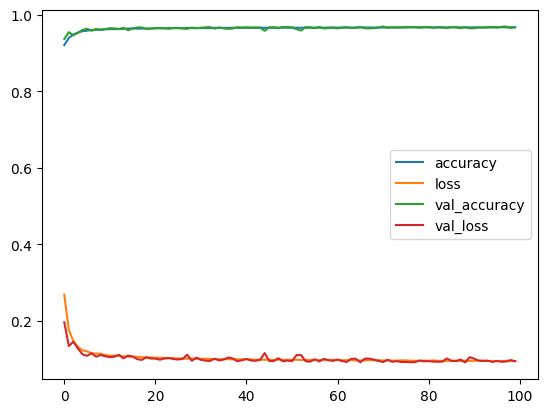

In [ ]:
# Ploting History of Training
pd.DataFrame(history.history).plot()

In [ ]:
Evaluation = model.evaluate(X.iloc[80000:],y.iloc[80000:])
Prediction_probabilities = model.predict(X_test)
Pred_Label,Ground_Truth = pd.DataFrame(tf.round(Prediction_probabilities)).iloc[9334] , y_test.iloc[9334]

from sklearn.metrics import confusion_matrix
print(f'Confussion matrix {confusion_matrix(y_test,pd.DataFrame(tf.round(Prediction_probabilities)))}\nLoss & Accuracy {Evaluation} \nGround Truth = {Ground_Truth}\n Pred Label = {Pred_Label}')

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9683 - loss: 0.0899
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step
Confussion matrix [[18228    64]
 [  567  1141]]
Loss & Accuracy [0.08967791497707367, 0.9681500196456909] 
Ground Truth = diabetes    1
Name: 44749, dtype: int64
 Pred Label = 0    1.0
Name: 9334, dtype: float32


In [ ]:
from sklearn.metrics import f1_score
f1_score(y_test,pd.DataFrame(tf.round(Prediction_probabilities)))

0.7833848266392036

In [ ]:
model.save('Diabetes_Detection_Model.keras')

In [ ]:
model = tf.keras.models.load_model('Diabetes_Detection_Model.keras')
from sklearn.metrics import f1_score
f1_score(y_test,pd.DataFrame(tf.round(model.predict(X_test))))

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step


0.7833848266392036

In [ ]:
Evaluation = model.evaluate(X.iloc[80000:],y.iloc[80000:])
Prediction_probabilities = model.predict(X_test)
Pred_Label,Ground_Truth = pd.DataFrame(tf.round(Prediction_probabilities)).iloc[9334] , y_test.iloc[9334]

from sklearn.metrics import confusion_matrix
print(f'Confussion matrix {confusion_matrix(y_test,pd.DataFrame(tf.round(Prediction_probabilities)))}\nLoss & Accuracy {Evaluation} \nGround Truth = {Ground_Truth}\n Pred Label = {Pred_Label}')

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 739us/step - accuracy: 0.9683 - loss: 0.0899
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 507us/step
Confussion matrix [[18228    64]
 [  567  1141]]
Loss & Accuracy [0.08967791497707367, 0.9681500196456909] 
Ground Truth = diabetes    1
Name: 44749, dtype: int64
 Pred Label = 0    1.0
Name: 9334, dtype: float32
